In [1]:
import os
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

In [2]:
# Essential libraries
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import spearmanr, skew
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from catboost import CatBoostRegressor
import torch

In [3]:
# Set random seed for reproducibility
seed = 69
torch.manual_seed(seed)
np.random.seed(seed)

In [4]:
# Define root directory
root = '.'

In [5]:
data = pd.read_csv('./new_dataset/maison-llf-features.CSV', sep=",")

In [6]:
# Convert tensors to pandas DataFrame
siss = data["sis"]  ### data[["sis", "ohs", "oks"]]

In [7]:
participants = data["participant"]

In [8]:
# Display unique participants and their counts
unique_values, counts = np.unique(participants, return_counts=True)
print(unique_values)
print(counts)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
[56 56 56 56 56 56 56 56 56 56 56 56 56 56 56 56 56 56]


In [9]:
# Initialize variables
x = data.iloc[:, -46:]
y = siss
p = participants

In [10]:
Y_TRUES = np.empty([0])
Y_PREDS = np.empty([0])

In [11]:
x

,acceleration-count,acceleration-mean,acceleration-std,acceleration-sum,acceleration-entropy,acceleration-kurtosis,acceleration-skew,acceleration-coefficient-of-variation,acceleration-minutes-with-data,acceleration-hours-with-data,...,sleep-duration-to-wakeup,sleep-wakeup-count,sleep-heartrate-mean,sleep-heartrate-min,sleep-heartrate-max,step-count,step-ratio,step-mean,step-max,step-max-timestamp
0,8499,9.8094,0.4333,83370.5096,3.6984,261.0654,8.9815,0.0442,1410,24,...,0.0000,3,59,54,74,415,0.5000,34.5833,106,13
1,5578,9.8284,0.4084,54822.8386,3.9855,88.4960,3.7246,0.0416,866,14,...,0.0000,4,61,56,82,447,0.2917,63.8571,185,8
2,9036,9.8315,0.4115,88826.4654,3.9544,216.9277,6.3666,0.0419,1162,19,...,0.1700,3,59,55,83,533,0.4231,56.1132,170,14
3,7201,9.8380,0.4797,70843.2369,4.0274,118.3102,3.7725,0.0488,382,6,...,0.0000,1,59,54,72,530,0.2083,106.0000,288,22
4,28362,9.8297,0.3174,278788.8663,4.2928,257.2173,6.2899,0.0323,1127,19,...,0.0000,2,61,56,73,686,0.3750,76.2222,176,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1003,3729,9.8208,0.5374,36621.6157,2.2141,29.8247,1.8650,0.0547,544,9,...,0.1833,1,50,41,60,2018,0.4583,183.4545,370,8
1004,3506,9.8529,0.5850,34544.3730,2.5908,15.8625,0.7094,0.0594,562,9,...,0.1833,7,46,41,59,5234,0.4583,475.8182,3052,14
1005,9571,9.8635,0.5036,94403.7198,3.1941,24.1882,1.2782,0.0511,402,7,...,0.1833,7,49,39,70,783,0.2917,111.8571,367,17
1006,7961,9.8452,0.6230,68145.9124,2.7985,27.4351,1.7590,0.0609,466,7,...,0.1833,10,51,41,74,4666,0.3531,741.5590,2061,15


In [12]:
# Perform cross-validation
cv = KFold(n_splits=x.shape[0], shuffle=True, random_state=seed)   ### 574 fold, cioè 574 cross-valid con 1 record di test solo

for fold, (train_idx, test_idx) in enumerate(cv.split(x), start=1):
    
    participant = np.unique(p[test_idx])[0]
    
    x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]  

    print(participant, x_train.shape[0], x_test.shape[0])
    
    # Standardize features
    scaler = StandardScaler()             #### https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
    scaler.fit(x_train)                   #### quella che in statistica è la normalizzazione
    x_train = scaler.transform(x_train)   
    x_test = scaler.transform(x_test)
    
    # Normalize features
    normalizer = MinMaxScaler()          #### una volta normalizzata, porto tutto nell'intervallo [0, 1]
    normalizer.fit(x_train)
    x_train = normalizer.transform(x_train)
    x_test = normalizer.transform(x_test)
    
    # Train model (CatBoostRegressor)
    model = CatBoostRegressor(
        iterations=100,  ## 1000
        learning_rate=.1,
        depth=3,
        loss_function='RMSE',
        verbose=10000
    )
    
    model.fit(
        x_train, y_train,
        eval_set=(x_test, y_test),
        use_best_model=True,
        early_stopping_rounds=100
    )
    y_preds = model.predict(x_test)

    # Append results
    Y_TRUES = np.append(Y_TRUES, y_test)
    Y_PREDS = np.append(Y_PREDS, y_preds)

18 1007 1
0:	learn: 3.7222856	test: 2.8829623	best: 2.8829623 (0)	total: 143ms	remaining: 14.2s
99:	learn: 1.8015150	test: 0.0339626	best: 0.0125377 (82)	total: 294ms	remaining: 0us

bestTest = 0.01253774773
bestIteration = 82

Shrink model to first 83 iterations.
10 1007 1
0:	learn: 3.7199215	test: 3.7999570	best: 3.7999570 (0)	total: 3.17ms	remaining: 314ms
99:	learn: 1.7897511	test: 2.8657258	best: 2.7208370 (21)	total: 197ms	remaining: 0us

bestTest = 2.720836975
bestIteration = 21

Shrink model to first 22 iterations.
16 1007 1
0:	learn: 3.7212879	test: 3.8816128	best: 3.8816128 (0)	total: 3.17ms	remaining: 313ms
99:	learn: 1.7795161	test: 2.9790613	best: 2.3692428 (15)	total: 195ms	remaining: 0us

bestTest = 2.369242843
bestIteration = 15

Shrink model to first 16 iterations.
8 1007 1
0:	learn: 3.7222308	test: 0.6518682	best: 0.6518682 (0)	total: 1.79ms	remaining: 178ms
99:	learn: 1.7822607	test: 0.3422287	best: 0.0003838 (4)	total: 164ms	remaining: 0us

bestTest = 0.000383768468

13 1007 1
0:	learn: 3.7190461	test: 2.9061947	best: 2.9061947 (0)	total: 2.01ms	remaining: 199ms
99:	learn: 1.7782795	test: 0.5895358	best: 0.5695311 (97)	total: 154ms	remaining: 0us

bestTest = 0.5695310944
bestIteration = 97

Shrink model to first 98 iterations.
9 1007 1
0:	learn: 3.7245143	test: 1.8197888	best: 1.8197888 (0)	total: 4.06ms	remaining: 402ms
99:	learn: 1.7962758	test: 0.0823442	best: 0.0007409 (75)	total: 189ms	remaining: 0us

bestTest = 0.0007409356037
bestIteration = 75

Shrink model to first 76 iterations.
15 1007 1
0:	learn: 3.7214496	test: 1.5364580	best: 1.5364580 (0)	total: 2.22ms	remaining: 220ms
99:	learn: 1.7812044	test: 1.3587928	best: 0.0507001 (11)	total: 220ms	remaining: 0us

bestTest = 0.05070006931
bestIteration = 11

Shrink model to first 12 iterations.
8 1007 1
0:	learn: 3.7149491	test: 7.6618187	best: 7.6618187 (0)	total: 2.08ms	remaining: 206ms
99:	learn: 1.7810502	test: 5.3609989	best: 5.2635581 (31)	total: 295ms	remaining: 0us

bestTest = 5.263558

99:	learn: 1.7923786	test: 1.7920872	best: 0.8806287 (0)	total: 417ms	remaining: 0us

bestTest = 0.8806287004
bestIteration = 0

Shrink model to first 1 iterations.
9 1007 1
0:	learn: 3.7214518	test: 2.6547110	best: 2.6547110 (0)	total: 3.17ms	remaining: 314ms
99:	learn: 1.8025316	test: 1.6174610	best: 0.0019452 (19)	total: 407ms	remaining: 0us

bestTest = 0.001945215199
bestIteration = 19

Shrink model to first 20 iterations.
6 1007 1
0:	learn: 3.7249222	test: 2.2179366	best: 2.2179366 (0)	total: 2.25ms	remaining: 223ms
99:	learn: 1.8044127	test: 0.5883680	best: 0.0002664 (55)	total: 402ms	remaining: 0us

bestTest = 0.0002663868463
bestIteration = 55

Shrink model to first 56 iterations.
13 1007 1
0:	learn: 3.7211693	test: 1.7299145	best: 1.7299145 (0)	total: 2.88ms	remaining: 285ms
99:	learn: 1.8020304	test: 0.4100892	best: 0.3245016 (98)	total: 442ms	remaining: 0us

bestTest = 0.324501624
bestIteration = 98

Shrink model to first 99 iterations.
4 1007 1
0:	learn: 3.7377633	test: 2.3

0:	learn: 3.7229232	test: 4.6190978	best: 4.6190978 (0)	total: 6.71ms	remaining: 664ms
99:	learn: 1.7947754	test: 3.2030412	best: 2.3446773 (23)	total: 463ms	remaining: 0us

bestTest = 2.344677314
bestIteration = 23

Shrink model to first 24 iterations.
14 1007 1
0:	learn: 3.7230059	test: 0.8780910	best: 0.8780910 (0)	total: 5.4ms	remaining: 535ms
99:	learn: 1.7908992	test: 0.1398333	best: 0.0006038 (15)	total: 456ms	remaining: 0us

bestTest = 0.0006038456471
bestIteration = 15

Shrink model to first 16 iterations.
5 1007 1
0:	learn: 3.7206604	test: 4.8827856	best: 4.8827856 (0)	total: 3ms	remaining: 297ms
99:	learn: 1.7941884	test: 1.0338286	best: 1.0338286 (99)	total: 272ms	remaining: 0us

bestTest = 1.033828613
bestIteration = 99

1 1007 1
0:	learn: 3.7349265	test: 1.7685960	best: 1.7685960 (0)	total: 1.74ms	remaining: 172ms
99:	learn: 1.8159146	test: 1.6929665	best: 1.4143338 (13)	total: 222ms	remaining: 0us

bestTest = 1.414333767
bestIteration = 13

Shrink model to first 14 itera

0:	learn: 3.7125999	test: 8.5152527	best: 8.5152527 (0)	total: 2.92ms	remaining: 290ms
99:	learn: 1.7730498	test: 4.9672090	best: 4.8231921 (94)	total: 182ms	remaining: 0us

bestTest = 4.823192117
bestIteration = 94

Shrink model to first 95 iterations.
9 1007 1
0:	learn: 3.7239066	test: 2.8212874	best: 2.8212874 (0)	total: 4.12ms	remaining: 407ms
99:	learn: 1.7793829	test: 0.6412093	best: 0.6324941 (89)	total: 199ms	remaining: 0us

bestTest = 0.6324941004
bestIteration = 89

Shrink model to first 90 iterations.
6 1007 1
0:	learn: 3.7197635	test: 0.5736278	best: 0.5736278 (0)	total: 3.68ms	remaining: 364ms
99:	learn: 1.8115427	test: 0.7393957	best: 0.0791634 (6)	total: 188ms	remaining: 0us

bestTest = 0.07916335202
bestIteration = 6

Shrink model to first 7 iterations.
18 1007 1
0:	learn: 3.7212879	test: 3.8816128	best: 3.8816128 (0)	total: 3.62ms	remaining: 359ms
99:	learn: 1.8163107	test: 0.1790477	best: 0.0032256 (86)	total: 272ms	remaining: 0us

bestTest = 0.003225617842
bestIterat

...

0:	learn: 3.7212762	test: 2.9018307	best: 2.9018307 (0)	total: 6.68ms	remaining: 662ms
99:	learn: 1.7892494	test: 1.0568129	best: 0.0674789 (17)	total: 528ms	remaining: 0us

bestTest = 0.06747885954
bestIteration = 17

Shrink model to first 18 iterations.
6 1007 1
0:	learn: 3.7229785	test: 1.1217066	best: 1.1217066 (0)	total: 6.14ms	remaining: 608ms
99:	learn: 1.7919699	test: 2.6395482	best: 0.9482857 (3)	total: 402ms	remaining: 0us

bestTest = 0.9482856952
bestIteration = 3

Shrink model to first 4 iterations.
13 1007 1
0:	learn: 3.7243527	test: 1.7887474	best: 1.7887474 (0)	total: 3.58ms	remaining: 354ms
99:	learn: 1.7816529	test: 1.5235484	best: 0.8359080 (44)	total: 437ms	remaining: 0us

bestTest = 0.8359079977
bestIteration = 44

Shrink model to first 45 iterations.
2 1007 1
0:	learn: 3.7320519	test: 0.0617986	best: 0.0617986 (0)	total: 3.13ms	remaining: 310ms
99:	learn: 1.7781811	test: 0.1154498	best: 0.0617986 (0)	total: 420ms	remaining: 0us

bestTest = 0.06179859162
bestIterati

0:	learn: 3.7264352	test: 2.7893250	best: 2.7893250 (0)	total: 4.93ms	remaining: 488ms
99:	learn: 1.7988433	test: 1.5563882	best: 1.4033384 (76)	total: 325ms	remaining: 0us

bestTest = 1.403338412
bestIteration = 76

Shrink model to first 77 iterations.
12 1007 1
0:	learn: 3.7203358	test: 4.8852959	best: 4.8852959 (0)	total: 3.14ms	remaining: 311ms
99:	learn: 1.8010160	test: 1.2419101	best: 1.2264268 (97)	total: 379ms	remaining: 0us

bestTest = 1.226426759
bestIteration = 97

Shrink model to first 98 iterations.
18 1007 1
0:	learn: 3.7188359	test: 5.8844964	best: 5.8844964 (0)	total: 5.02ms	remaining: 497ms
99:	learn: 1.7702929	test: 0.9108086	best: 0.8811853 (96)	total: 488ms	remaining: 0us

bestTest = 0.8811852972
bestIteration = 96

Shrink model to first 97 iterations.
5 1007 1
0:	learn: 3.7193307	test: 5.2837629	best: 5.2837629 (0)	total: 4.99ms	remaining: 494ms
99:	learn: 1.7840052	test: 3.5262870	best: 3.5262870 (99)	total: 408ms	remaining: 0us

bestTest = 3.526287026
bestIterati

99:	learn: 1.7790649	test: 1.1819380	best: 1.1247926 (96)	total: 589ms	remaining: 0us

bestTest = 1.124792584
bestIteration = 96

Shrink model to first 97 iterations.
9 1007 1
0:	learn: 3.7219407	test: 1.3509763	best: 1.3509763 (0)	total: 3.35ms	remaining: 331ms
99:	learn: 1.8031613	test: 3.2847125	best: 1.3509763 (0)	total: 462ms	remaining: 0us

bestTest = 1.350976263
bestIteration = 0

Shrink model to first 1 iterations.
6 1007 1
0:	learn: 3.7224613	test: 2.2803178	best: 2.2803178 (0)	total: 5.35ms	remaining: 530ms
99:	learn: 1.7892138	test: 1.2370593	best: 1.2192403 (72)	total: 524ms	remaining: 0us

bestTest = 1.219240332
bestIteration = 72

Shrink model to first 73 iterations.
8 1007 1
0:	learn: 3.7221040	test: 1.6532887	best: 1.6532887 (0)	total: 7.37ms	remaining: 729ms
99:	learn: 1.7861327	test: 0.9226338	best: 0.0114894 (16)	total: 404ms	remaining: 0us

bestTest = 0.01148940053
bestIteration = 16

Shrink model to first 17 iterations.
17 1007 1
0:	learn: 3.7229785	test: 1.1217066

0:	learn: 3.7374356	test: 1.9177234	best: 1.9177234 (0)	total: 5.52ms	remaining: 546ms
99:	learn: 1.8301344	test: 0.5427054	best: 0.0072569 (13)	total: 425ms	remaining: 0us

bestTest = 0.007256921023
bestIteration = 13

Shrink model to first 14 iterations.
18 1007 1
0:	learn: 3.7220030	test: 2.8804092	best: 2.8804092 (0)	total: 6.86ms	remaining: 679ms
99:	learn: 1.7879894	test: 1.1779212	best: 0.0279751 (22)	total: 547ms	remaining: 0us

bestTest = 0.02797512688
bestIteration = 22

Shrink model to first 23 iterations.
16 1007 1
0:	learn: 3.7214445	test: 3.8841299	best: 3.8841299 (0)	total: 6.42ms	remaining: 636ms
99:	learn: 1.7739842	test: 0.8601694	best: 0.6160958 (53)	total: 455ms	remaining: 0us

bestTest = 0.6160957774
bestIteration = 53

Shrink model to first 54 iterations.
14 1007 1
0:	learn: 3.7268522	test: 2.8647592	best: 2.8647592 (0)	total: 7.58ms	remaining: 750ms
99:	learn: 1.8090180	test: 0.4736215	best: 0.0200664 (53)	total: 536ms	remaining: 0us

bestTest = 0.02006638613
bes

0:	learn: 3.7354854	test: 6.0854409	best: 6.0854409 (0)	total: 6.51ms	remaining: 644ms
99:	learn: 1.8039539	test: 6.9256820	best: 6.0854409 (0)	total: 524ms	remaining: 0us

bestTest = 6.085440948
bestIteration = 0

Shrink model to first 1 iterations.
17 1007 1
0:	learn: 3.7212110	test: 1.2086819	best: 1.2086819 (0)	total: 7.28ms	remaining: 721ms
99:	learn: 1.7855949	test: 1.5700846	best: 0.8878733 (49)	total: 548ms	remaining: 0us

bestTest = 0.8878733043
bestIteration = 49

Shrink model to first 50 iterations.
8 1007 1
0:	learn: 3.7222308	test: 0.6518682	best: 0.6518682 (0)	total: 9.54ms	remaining: 945ms
99:	learn: 1.8117016	test: 2.1699532	best: 0.0350712 (4)	total: 594ms	remaining: 0us

bestTest = 0.03507119408
bestIteration = 4

Shrink model to first 5 iterations.
2 1007 1
0:	learn: 3.7316631	test: 2.1075331	best: 2.1075331 (0)	total: 6.29ms	remaining: 623ms
99:	learn: 1.7865109	test: 3.6202981	best: 2.1075331 (0)	total: 587ms	remaining: 0us

bestTest = 2.107533127
bestIteration = 0

In [13]:
# Sort results for plotting
indx = Y_TRUES.argsort()
Y_TRUES = Y_TRUES[indx]
Y_PREDS = Y_PREDS[indx]

In [14]:
Y_TRUES

array([15., 15., 15., ..., 30., 30., 30.])

In [15]:
Y_PREDS

array([17.45993469, 18.42539241, 19.83635106, ..., 28.93276785,
       28.55522958, 28.44959265])

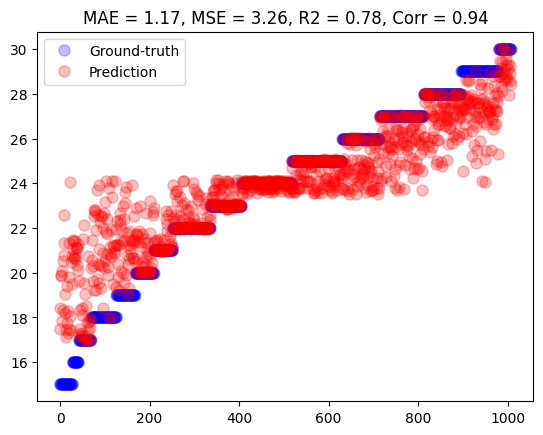

In [16]:
# Plot results
plt.figure()
plt.plot(Y_TRUES, 'o', color='blue', alpha=.25, markersize=8, label='Ground-truth')
plt.plot(Y_PREDS, 'o', color='red', alpha=.25, markersize=8, label='Prediction')
plt.title('MAE = ' + str(mean_absolute_error(Y_TRUES, Y_PREDS).__round__(2)) +
          ', MSE = ' + str(mean_squared_error(Y_TRUES, Y_PREDS).__round__(2)) +
          ', R2 = ' + str(r2_score(Y_TRUES, Y_PREDS).__round__(2)) +
          ', Corr = ' + str(spearmanr(Y_TRUES, Y_PREDS)[0].__round__(2)))
plt.legend()
plt.show()

In [17]:
# Print performance metrics
print('MAE = ' + str(mean_absolute_error(Y_TRUES, Y_PREDS).__round__(2)) +
      ', MSE = ' + str(mean_squared_error(Y_TRUES, Y_PREDS).__round__(2)) +
      ', R2 = ' + str(r2_score(Y_TRUES, Y_PREDS).__round__(2)) +
      ', Corr = ' + str(spearmanr(Y_TRUES, Y_PREDS)[0].__round__(2)))

MAE = 1.17, MSE = 3.26, R2 = 0.78, Corr = 0.94
